In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel("C:\\Users\\ASUS\\Downloads\\DataScience\\Dataset for Data Analytics.xlsx")
print(df.head())
print(df.info())


     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [3]:
missing = df.isnull().mean() * 100
print(missing)


OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64


In [5]:
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')
df['ReferralSource'] = df['ReferralSource'].fillna(df['ReferralSource'].mode()[0])



In [7]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

df['UnitPrice'] = np.clip(df['UnitPrice'], lower, upper)


In [8]:
df['DiscountApplied'] = df['CouponCode'].apply(lambda x: 0 if x=='NO_COUPON' else 1)


In [9]:
df['OrderValuePerItem'] = df['TotalPrice'] / df['Quantity']


In [10]:
df['IsHighValueCustomer'] = (df['TotalPrice'] > 2000).astype(int)


In [11]:
df = pd.get_dummies(df, columns=['PaymentMethod','ReferralSource','OrderStatus'], drop_first=True)


TotalPrice             1.000000
IsHighValueCustomer    0.773466
OrderValuePerItem      0.717081
UnitPrice              0.717081
Quantity               0.615251
ItemsInCart            0.392540
DiscountApplied        0.007616
Name: TotalPrice, dtype: float64


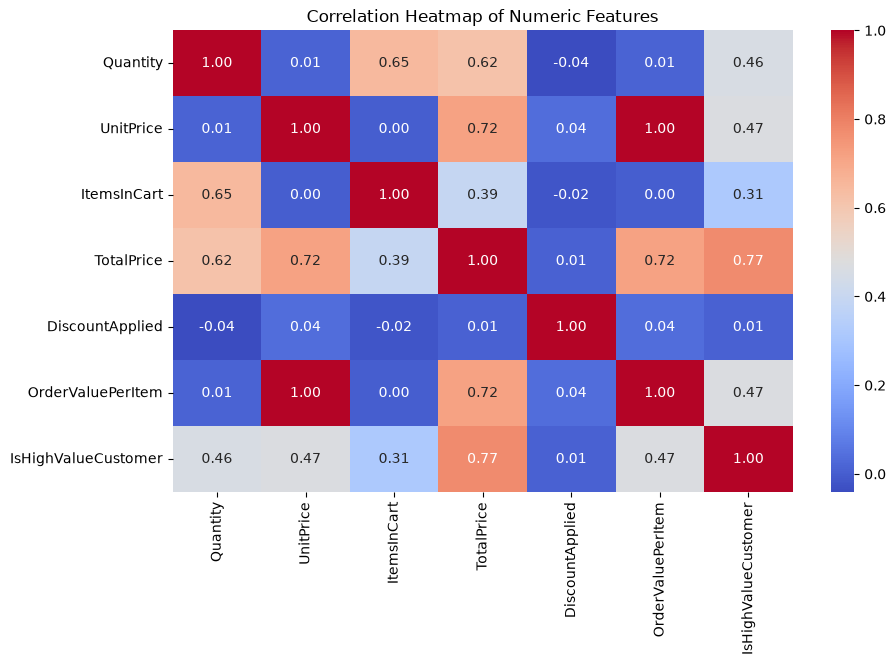

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=['number'])


corr = numeric_df.corr()


print(corr['TotalPrice'].sort_values(ascending=False))


plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [16]:
!pip install pandera

import pandera as pa

schema = pa.DataFrameSchema({
    "Quantity": pa.Column(int, checks=pa.Check.ge(1)),
    "UnitPrice": pa.Column(float, checks=pa.Check.ge(0)),
    "TotalPrice": pa.Column(float, checks=pa.Check.ge(0))
})

schema.validate(df)


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 3.2 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 3.6 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.5 MB/s  0:00:00

   ---------- ----------------------------- 2/8 [pydantic-core]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ----------------------------------- ---- 7/8 [pandera]
   ----------------------------------- ---- 7/8 [pandera]
   ----------------------------------- ---- 7/8 [pandera]
   ----------------------------------

C:\Users\ASUS\anaconda3\envs\Krushnaenv\Lib\site-packages\pandera\_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,...,PaymentMethod_Gift Card,PaymentMethod_Online,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,TRK37947903,7,SAVE10,...,False,False,False,False,True,False,False,False,False,True
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,TRK91186779,3,SAVE10,...,False,True,False,False,False,True,False,False,False,True
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,TRK42903982,8,FREESHIP,...,False,False,False,False,False,False,False,False,False,False
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,TRK62788070,5,SAVE10,...,False,False,True,False,False,False,False,False,True,False
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,TRK29241424,8,SAVE10,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,TRK38009181,6,FREESHIP,...,False,False,False,True,False,False,False,False,False,False
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,TRK69207593,5,NO_COUPON,...,False,True,True,False,False,False,False,False,False,False
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,TRK88039356,2,FREESHIP,...,False,True,False,False,True,False,True,False,False,False
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,TRK71683331,4,WINTER15,...,False,False,False,False,True,False,False,False,False,False


In [17]:
import pandera.pandas as pa

schema = pa.DataFrameSchema({
    "Quantity": pa.Column(int, checks=pa.Check.ge(1)),
    "UnitPrice": pa.Column(float, checks=pa.Check.ge(0)),
    "TotalPrice": pa.Column(float, checks=pa.Check.ge(0))
})

schema.validate(df)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,...,PaymentMethod_Gift Card,PaymentMethod_Online,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,TRK37947903,7,SAVE10,...,False,False,False,False,True,False,False,False,False,True
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,TRK91186779,3,SAVE10,...,False,True,False,False,False,True,False,False,False,True
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,TRK42903982,8,FREESHIP,...,False,False,False,False,False,False,False,False,False,False
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,TRK62788070,5,SAVE10,...,False,False,True,False,False,False,False,False,True,False
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,TRK29241424,8,SAVE10,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,TRK38009181,6,FREESHIP,...,False,False,False,True,False,False,False,False,False,False
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,TRK69207593,5,NO_COUPON,...,False,True,True,False,False,False,False,False,False,False
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,TRK88039356,2,FREESHIP,...,False,True,False,False,True,False,True,False,False,False
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,TRK71683331,4,WINTER15,...,False,False,False,False,True,False,False,False,False,False


In [18]:
# Example: instead of for-loop, use vectorized operations
df['OrderValuePerItem'] = df['TotalPrice'] / df['Quantity']
df['IsHighValueCustomer'] = (df['TotalPrice'] > 2000).astype(int)


In [19]:
df = pd.get_dummies(df, columns=['PaymentMethod','ReferralSource','OrderStatus'], drop_first=True)


KeyError: "None of [Index(['PaymentMethod', 'ReferralSource', 'OrderStatus'], dtype='str')] are in the [columns]"

In [20]:
# Correlation matrix
corr_matrix = df.select_dtypes(include=['number']).corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Dropping due to collinearity:", to_drop)

df = df.drop(columns=to_drop)


Dropping due to collinearity: ['OrderValuePerItem']


In [22]:
import pandas as pd

def encode_categoricals(df):
    """
    Automatically detect categorical string columns and apply One-Hot Encoding.
    Drops the first category to avoid dummy variable trap.
    Returns the encoded dataframe.
    """
    # Detect string columns (future-proof)
    categorical_cols = df.select_dtypes(include=['object', 'string']).columns
    print("Categorical columns detected:", list(categorical_cols))
    
    # Apply One-Hot Encoding safely
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    print("Encoding complete. New shape:", df_encoded.shape)
    return df_encoded

# ✅ Usage
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df_encoded = encode_categoricals(df)

# Save encoded dataset
df_encoded.to_csv("Encoded_Dataset.csv", index=False)


Categorical columns detected: ['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']
Encoding complete. New shape: (1200, 4265)


In [23]:
corr_matrix = df.select_dtypes(include=['number']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
df = df.drop(columns=to_drop)


In [24]:
import pandera.pandas as pa

schema = pa.DataFrameSchema({
    "Quantity": pa.Column(int, checks=pa.Check.ge(1)),
    "UnitPrice": pa.Column(float, checks=pa.Check.ge(0)),
    "TotalPrice": pa.Column(float, checks=pa.Check.ge(0))
}, coerce=True)

# Lazy validation: collect all errors at once
schema.validate(df, lazy=True)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [25]:
df.to_csv("C:\\Users\\ASUS\\Downloads\\DataScience\\Cleaned_Dataset.csv", index=False)
